# The second case: the auditor's question, solution

**Week 1, Wednesday afternoon, the second case, solution twin.** Every placeholder filled, run
clean. The letters, in order: 1b 2a 3b 4b 5c.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

def apply_rule(rows, key, prefer):
    """One row per key; prefer is "validates" or "first". Returns (kept, set aside)."""
    kept, aside = {}, []
    for r in rows:
        k = r[key] if isinstance(key, str) and key in r else tuple(sorted(r.items()))
        if k not in kept:
            kept[k] = r
        elif prefer == "validates" and convert(kept[k]["amount"])[0] is None and convert(r["amount"])[0] is not None:
            aside.append(kept[k]); kept[k] = r
        else:
            aside.append(r)
    good = [dict(r, amount=convert(r["amount"])[0]) for r in kept.values() if convert(r["amount"])[0] is not None]
    aside += [r for r in kept.values() if convert(r["amount"])[0] is None]
    return good, aside

def per_customer(rows, q, seg):
    rs = [r for r in rows if r["quarter"] == q and r["segment"] == seg]
    return len(rs) / len({r["customer_id"] for r in rs})

raw = read_orders()
clean, set_aside = apply_rule(raw, "order_id", "validates")
by_id = {}
for r in raw:
    by_id.setdefault(r["order_id"], []).append(r)
q1_aside = [r for r in set_aside if r["quarter"] == "Q1"]
print(len(clean), "orders kept;", len(q1_aside), "Q1 rows set aside")

186 orders kept; 14 Q1 rows set aside


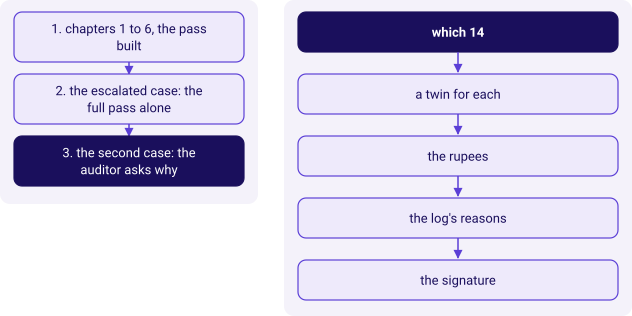

In [2]:
kit.side_by_side(
    kit.ladder(["chapters 1 to 6, the pass built", "the escalated case: the full pass alone",
            "the second case: the auditor asks why"], lit=2, show=False),
    kit.vflow(["which 14", "a twin for each", "the rupees", "the log's reasons", "the signature"], lit=0, show=False),
)

## Question 1. How many Q1 rows were set aside, and is that the auditor's 14?

In [3]:
# TODO 1. Which count answers the auditor's first question?
#   a) rows in the file less orders kept, both quarters
#   b) Q1 rows in less Q1 orders kept
#   c) distinct order ids in Q1
#   d) rows in the rejects log
q1_in = sum(1 for r in raw if r["quarter"] == "Q1")
q1_kept = sum(1 for r in clean if r["quarter"] == "Q1")
answer_1 = q1_in - q1_kept
print("Question 1: done")

Question 1: done


**Why the other letters fail.** b. the auditor asked about Q1. a counts both quarters and gives 15, c counts orders, not rows, and d counts the one unreadable amount.

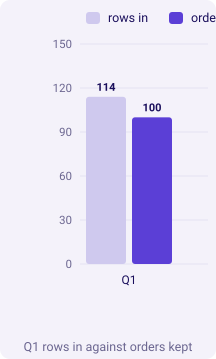

In [4]:
kit.check("the auditor's 14 is Q1 rows in less Q1 orders kept", answer_1 == 14, f"{answer_1}")
kit.columns(["Q1"], [("rows in", [q1_in]), ("orders kept", [q1_kept])], title="Q1 rows in against orders kept")

## Question 2. Is every one of the 14 a second copy of a kept order?

In [5]:
# TODO 2. Which test shows each set-aside row has a twin that stayed?
#   a) its order_id appears among the kept orders
#   b) its amount appears among the kept orders
#   c) its customer_id appears among the kept orders
#   d) its line number is above 186
kept_ids = {r["order_id"] for r in clean}
has_twin = [r["order_id"] in kept_ids for r in q1_aside]
print("Question 2: done")

Question 2: done


**Why the other letters fail.** a. a twin is the same order_id. b and c match different orders that happen to share a value or a buyer, and d is where a row sits, not what it is.

In [6]:
kit.check("all 14 have a kept twin", all(has_twin) and len(has_twin) == 14)

## Question 3. Which rows carry the rupees?

In [7]:
# TODO 3. How should the rupees be shown to the auditor?
#   a) one total for all 14 rows
#   b) split by the segment of each row, rows and rupees side by side
#   c) only the largest row, since it dominates
#   d) as a share of Q2 revenue
segs = ["Business", "Retail-Plus", "Retail-Core"]
rows_by = [sum(1 for r in q1_aside if r["segment"] == s) for s in segs]
rupees_by = [sum(convert(r["amount"])[0] or 0 for r in q1_aside if r["segment"] == s) for s in segs]
shown = list(zip(segs, rows_by, rupees_by))
print("Question 3: done")

Question 3: done


**Why the other letters fail.** b. the auditor needs rows and rupees by kind, since two rows carry 98 percent of the money. a hides that, c hides the other rows, and d answers a different quarter.

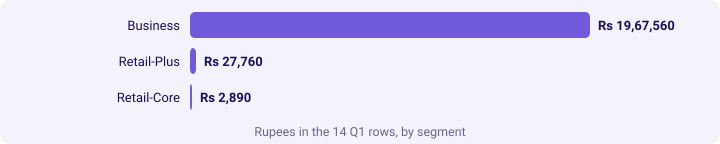

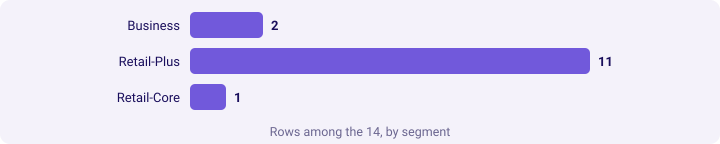

In [8]:
kit.check("the rupees add to Rs 19,98,210", sum(rupees_by) == 1998210, kit.rupees(sum(rupees_by)))
kit.bars(list(zip(segs, rupees_by)), fmt=kit.rupees, title="Rupees in the 14 Q1 rows, by segment")
kit.bars(list(zip(segs, rows_by)), title="Rows among the 14, by segment")

## Question 4. Why was one copy chosen over its twin?

In [9]:
# TODO 4. For a pair whose copies differ, what does the log have to say?
#   a) nothing, since the pair shares an id
#   b) which copy stayed, which field differed, and why that copy
#   c) the average of the two copies
#   d) that the pair was deleted
pairs_differing = [k for k, rs in by_id.items() if len(rs) > 1
                   and len({tuple((f, v) for f, v in r.items() if f != "line") for r in rs}) > 1]
log_rule = {"copy": "kept", "field": "which one differed", "why": "the copy that validates"}
print("Question 4: done")

Question 4: done


**Why the other letters fail.** b. a pair that differs needs the kept copy, the field and the reason. a leaves the auditor guessing, c invents a value, and d is false.

In [10]:
kit.check("two pairs differ between their copies", len(pairs_differing) == 2)
kit.check("the log states the copy, the field and the reason", "field" in log_rule and "why" in log_rule)

## Question 5. What does the auditor sign?

In [11]:
# TODO 5. Which statement is the one the evidence supports?
#   a) 14 Q1 rows were deleted as errors
#   b) the dashboard was right and the books are short
#   c) 14 Q1 rows are copies of kept orders, set aside by the order_id rule; rows and rupees reconcile
#   d) the 14 rows were outliers
statement = "14 Q1 rows are copies of kept orders, set aside by the order_id rule; rows and rupees reconcile"
print("Question 5: done")

Question 5: done


**Why the other letters fail.** c. it states the rule and both reconciliations. a calls copies errors and says deleted, b reverses the finding, and d confuses copies with outliers.

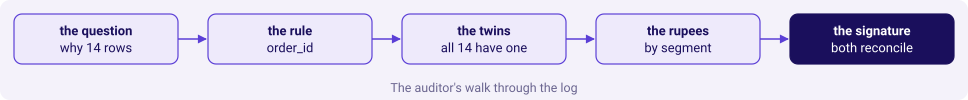

In [12]:
kit.check("rows reconcile in Q1", q1_in == q1_kept + len(q1_aside))
kit.check("rupees reconcile in Q1", Q(raw, "Q1") - sum(rupees_by) == 19000000)
kit.flow(["the question\nwhy 14 rows", "the rule\norder_id", "the twins\nall 14 have one",
          "the rupees\nby segment", "the signature\nboth reconcile"], lit=4, title="The auditor's walk through the log")
kit.check_summary()